In [70]:
import pandas as pd

In [71]:
df=pd.read_csv("D:/ML Internship/Encoding_Data.csv")
df

,id,bin_1,bin_2,nom_0,ord_2
0,0,F,N,Red,Hot
1,1,F,Y,Blue,Warm
2,2,F,N,Blue,Cold
3,3,F,N,Green,Warm
4,4,T,N,Red,Cold
5,5,T,N,Green,Hot
6,6,T,N,Red,Cold
7,7,T,N,Red,Cold
8,8,F,N,Blue,Warm
9,9,F,Y,Red,Hot


In [72]:
#Renaming the columns
df=df.rename(columns={"nom_0":"color","ord_2":"weather"})
df

,id,bin_1,bin_2,color,weather
0,0,F,N,Red,Hot
1,1,F,Y,Blue,Warm
2,2,F,N,Blue,Cold
3,3,F,N,Green,Warm
4,4,T,N,Red,Cold
5,5,T,N,Green,Hot
6,6,T,N,Red,Cold
7,7,T,N,Red,Cold
8,8,F,N,Blue,Warm
9,9,F,Y,Red,Hot


<Axes: xlabel='count', ylabel='bin_1'>

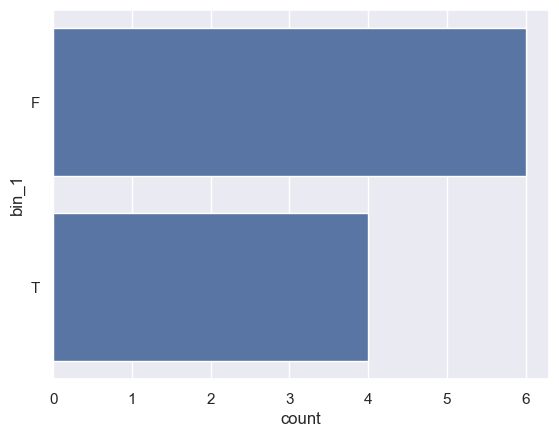

In [73]:
import seaborn as sns
sns.countplot(df["bin_1"])

<Axes: xlabel='count', ylabel='bin_2'>

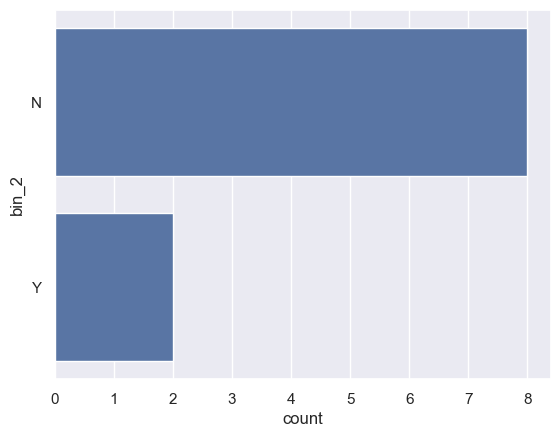

In [74]:
sns.countplot(df["bin_2"])

In [75]:
df.dtypes

id          int64
bin_1      object
bin_2      object
color      object
weather    object
dtype: object

In [76]:
# Mapping technique
df["bin_1"]=df["bin_1"].apply(
    lambda x: 1 if x=="T" else(0 if x=="F" else None))

In [77]:
df

,id,bin_1,bin_2,color,weather
0,0,0,N,Red,Hot
1,1,0,Y,Blue,Warm
2,2,0,N,Blue,Cold
3,3,0,N,Green,Warm
4,4,1,N,Red,Cold
5,5,1,N,Green,Hot
6,6,1,N,Red,Cold
7,7,1,N,Red,Cold
8,8,0,N,Blue,Warm
9,9,0,Y,Red,Hot


In [78]:
df["bin_2"]=df["bin_2"].apply(
    lambda x: 1 if x=="Y" else(0 if x=="N" else None))

In [79]:
df

,id,bin_1,bin_2,color,weather
0,0,0,0,Red,Hot
1,1,0,1,Blue,Warm
2,2,0,0,Blue,Cold
3,3,0,0,Green,Warm
4,4,1,0,Red,Cold
5,5,1,0,Green,Hot
6,6,1,0,Red,Cold
7,7,1,0,Red,Cold
8,8,0,0,Blue,Warm
9,9,0,1,Red,Hot


# Label Encoding

In [80]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["weather"]=le.fit_transform(df["weather"])
df["weather"]

0    1
1    2
2    0
3    2
4    0
5    1
6    0
7    0
8    2
9    1
Name: weather, dtype: int64

<Axes: xlabel='weather', ylabel='count'>

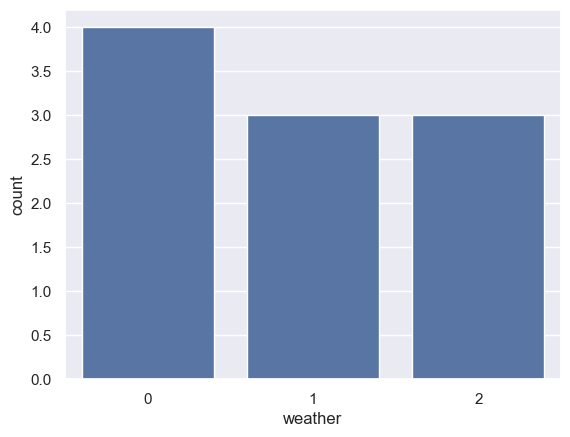

In [81]:
sns.set(style="darkgrid")
sns.countplot(x=df["weather"])

In [82]:
df.dtypes

id          int64
bin_1       int64
bin_2       int64
color      object
weather     int64
dtype: object

# One Hot Encoding

In [83]:
# method1
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder()
one=one.fit_transform(df[["color"]]).toarray()
encod=pd.DataFrame(one)
df=pd.concat([df,encod],axis=1)
df

,id,bin_1,bin_2,color,weather,0,1,2
0,0,0,0,Red,1,0.0,0.0,1.0
1,1,0,1,Blue,2,1.0,0.0,0.0
2,2,0,0,Blue,0,1.0,0.0,0.0
3,3,0,0,Green,2,0.0,1.0,0.0
4,4,1,0,Red,0,0.0,0.0,1.0
5,5,1,0,Green,1,0.0,1.0,0.0
6,6,1,0,Red,0,0.0,0.0,1.0
7,7,1,0,Red,0,0.0,0.0,1.0
8,8,0,0,Blue,2,1.0,0.0,0.0
9,9,0,1,Red,1,0.0,0.0,1.0


In [84]:
# Method2
df=pd.get_dummies(df,prefix="color",columns=["color"])
df

,id,bin_1,bin_2,weather,0,1,2,color_Blue,color_Green,color_Red
0,0,0,0,1,0.0,0.0,1.0,False,False,True
1,1,0,1,2,1.0,0.0,0.0,True,False,False
2,2,0,0,0,1.0,0.0,0.0,True,False,False
3,3,0,0,2,0.0,1.0,0.0,False,True,False
4,4,1,0,0,0.0,0.0,1.0,False,False,True
5,5,1,0,1,0.0,1.0,0.0,False,True,False
6,6,1,0,0,0.0,0.0,1.0,False,False,True
7,7,1,0,0,0.0,0.0,1.0,False,False,True
8,8,0,0,2,1.0,0.0,0.0,True,False,False
9,9,0,1,1,0.0,0.0,1.0,False,False,True


# Ordinal Encoding

In [85]:
from sklearn.preprocessing import OrdinalEncoder
orde=OneHotEncoder()
x=df[["bin_2"]]
output=orde.fit_transform(x)
output

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (10, 2)>

In [86]:
df

,id,bin_1,bin_2,weather,0,1,2,color_Blue,color_Green,color_Red
0,0,0,0,1,0.0,0.0,1.0,False,False,True
1,1,0,1,2,1.0,0.0,0.0,True,False,False
2,2,0,0,0,1.0,0.0,0.0,True,False,False
3,3,0,0,2,0.0,1.0,0.0,False,True,False
4,4,1,0,0,0.0,0.0,1.0,False,False,True
5,5,1,0,1,0.0,1.0,0.0,False,True,False
6,6,1,0,0,0.0,0.0,1.0,False,False,True
7,7,1,0,0,0.0,0.0,1.0,False,False,True
8,8,0,0,2,1.0,0.0,0.0,True,False,False
9,9,0,1,1,0.0,0.0,1.0,False,False,True
